# MetricTensor3D — Triclinic lattice geometry and the Bloch metric

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>
> Accepted local contract: `docs/harness/physkit.harness.09-dimensional-periodic-solids-notebook-series-contract.md`  
> Accepted contract SHA-256: `97736dc9bb9a5fcd3561b51fea8b2869ecbe1bbb4d1a8b7b2df9d0b4313b9ce9`

## Question

How do direct and reciprocal metrics generalize the earlier orthorhombic formulas to a triclinic cell?

## Learning objectives

- Construct a nondegenerate triclinic basis and its direct metric.
- Verify dual and reciprocal bases, volume, and reciprocal metric.
- Use the metric for periodic distances and plane-wave eigenvalues.
- Write the constant-metric Bloch Laplacian and recover the orthorhombic limit.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This is the capstone generalization of the complete dimensional notebook sequence.


## Triclinic metric and Bloch operator

For $\mathbf r=A\mathbf s$,

$$
g=A^TA,\qquad B=2\pi A^{-T},\qquad \Omega=\sqrt{\det g}=|\det A|.
$$

For constant $g$,

$$
\nabla^2=g^{ij}\partial_i\partial_j,
\qquad
\nabla_{\mathbf k}^2=g^{ij}(\partial_i+ik_i)(\partial_j+ik_j),
$$

where $k_i=\mathbf k\cdot\mathbf a_i=2\pi q_i$ for reduced reciprocal
coordinates $q_i$.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from itertools import product


def nearest_periodic_image(displacement_fractional, A):
    """Search neighboring lattice translations; suitable for this small teaching example."""
    center = np.rint(displacement_fractional).astype(int)
    shifts = np.array(list(product(*[range(c - 1, c + 2) for c in center])))
    candidates_fractional = displacement_fractional - shifts
    candidates_cartesian = candidates_fractional @ A.T
    index = np.argmin(np.einsum("ij,ij->i", candidates_cartesian, candidates_cartesian))
    return candidates_fractional[index], candidates_cartesian[index]

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
a1 = np.array([1.0, 0.0, 0.0])
a2 = np.array([0.20, 0.90, 0.0])
a3 = np.array([0.10, 0.25, 0.80])
A = np.column_stack([a1, a2, a3])
g = A.T @ A
g_inv = np.linalg.inv(g)
assert g.shape == (3, 3)
assert np.issubdtype(g.dtype, np.floating)
dual = np.linalg.inv(A).T
B = 2 * np.pi * dual
reciprocal_metric = B.T @ B
volume = np.sqrt(np.linalg.det(g))

assert np.all(np.linalg.eigvalsh(g) > 0.0)
assert np.allclose(A.T @ dual, np.eye(3), rtol=1e-10, atol=1e-12)
assert np.allclose(A.T @ B, 2 * np.pi * np.eye(3), rtol=1e-10, atol=1e-12)
assert np.allclose(reciprocal_metric, 4 * np.pi**2 * g_inv, rtol=1e-10, atol=1e-12)
assert np.isclose(volume, abs(np.linalg.det(A)), rtol=1e-10, atol=1e-12)
print("A=\n", A)
print("g=\n", g)
print("g^{-1}=\n", g_inv)
print("cell volume:", volume)


A=
 [[1.   0.2  0.1 ]
 [0.   0.9  0.25]
 [0.   0.   0.8 ]]
g=
 [[1.     0.2    0.1   ]
 [0.2    0.85   0.245 ]
 [0.1    0.245  0.7125]]
g^{-1}=
 [[ 1.052469 -0.227623 -0.069444]
 [-0.227623  1.355131 -0.434028]
 [-0.069444 -0.434028  1.5625  ]]
cell volume: 0.7200000000000001


In [3]:
fractional_displacement = np.array([0.58, 0.56, -0.52])
nearest_fractional, nearest_cartesian = nearest_periodic_image(fractional_displacement, A)
naive_fractional = fractional_displacement - np.rint(fractional_displacement)
naive_cartesian = A @ naive_fractional
assert np.linalg.norm(nearest_cartesian) <= np.linalg.norm(naive_cartesian) + 1e-12
print("nearest fractional image:", nearest_fractional)
print("nearest Cartesian image:", nearest_cartesian)
print("nearest distance:", np.linalg.norm(nearest_cartesian))


nearest fractional image: [-0.42 -0.44  0.48]
nearest Cartesian image: [-0.46  -0.276  0.384]
nearest distance: 0.6597211532155082


In [4]:
mode = np.array([1, -2, 1])
q = np.array([0.13, -0.08, 0.17])
G_cartesian = B @ mode
k_cartesian = B @ q
phase_components = A.T @ k_cartesian
assert np.allclose(phase_components, 2 * np.pi * q, rtol=1e-10, atol=1e-12)

free_bloch_value_metric = (2 * np.pi * (mode + q)) @ g_inv @ (2 * np.pi * (mode + q))
free_bloch_value_cartesian = np.dot(G_cartesian + k_cartesian, G_cartesian + k_cartesian)
assert np.isclose(free_bloch_value_metric, free_bloch_value_cartesian, rtol=1e-10, atol=1e-12)

orthogonal_lengths = np.array([1.0, 1.2, 1.5])
A_orthogonal = np.diag(orthogonal_lengths)
g_orthogonal = A_orthogonal.T @ A_orthogonal
assert np.allclose(g_orthogonal, np.diag(orthogonal_lengths**2), rtol=1e-10, atol=1e-12)
orthogonal_value = mode @ np.linalg.inv(g_orthogonal) @ mode
assert np.isclose(orthogonal_value, np.sum((mode / orthogonal_lengths) ** 2), rtol=1e-10, atol=1e-12)
print("covariant Bloch phase components:", phase_components)
print("free Bloch kinetic value:", free_bloch_value_metric)


covariant Bloch phase components: [ 0.816814 -0.502655  1.068142]
free Bloch kinetic value: 487.34254763284355


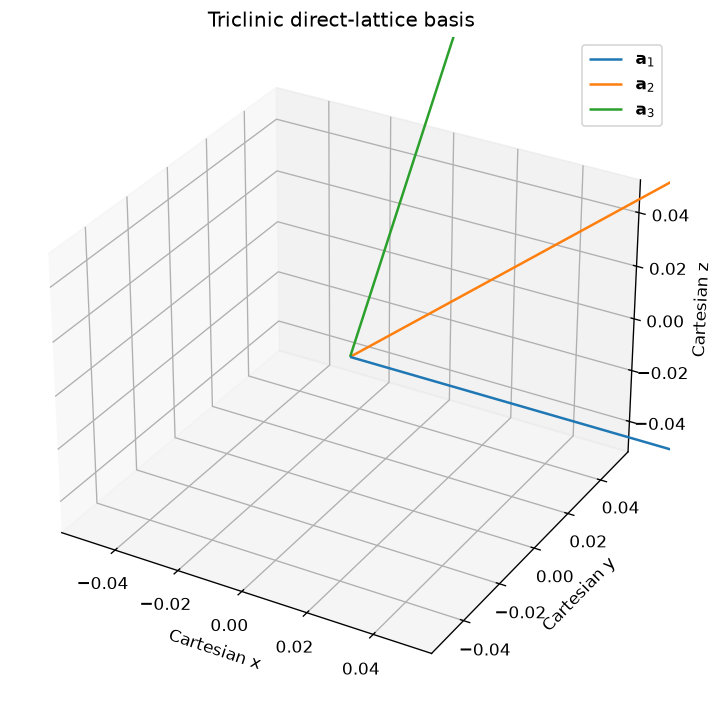

In [5]:
origin = np.zeros(3)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
colors = ["C0", "C1", "C2"]
labels = [r"$\mathbf{a}_1$", r"$\mathbf{a}_2$", r"$\mathbf{a}_3$"]
for vector, color, label in zip(A.T, colors, labels):
    ax.quiver(*origin, *vector, color=color, label=label)
ax.set(xlabel="Cartesian x", ylabel="Cartesian y", zlabel="Cartesian z", title="Triclinic direct-lattice basis")
ax.legend()
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

The metric is constant because the lattice basis is constant. General curvilinear coordinates require the full Laplace–Beltrami divergence form. No effective-mass, strain, dielectric, or constitutive tensor is inferred.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

This concludes the accepted notebook sequence by recovering the earlier orthogonal formulas as a special metric and exposing their non-orthogonal generalization.
